#https://jh-ml.nccs.nasa.gov/jupyterhub-prism/user/gtamkin/lab/tree/_CSDA-dev/notebooks/diff-bands.ipynb

In [1]:
import rioxarray as rxr
baseline_toa_path = '/panfs/ccds02/nobackup/projects/ilab/projects/srlite/input/RailroadValley/WV02_20200706_M1BS_10300100A8191000-toa.tif'
gt_evhr_toa_path = '/panfs/ccds02/nobackup/people/gtamkin/dev/CSDA/SystemTesting/testEVHR_RRV_ADAPT_01041846/5-toas/WV02_20200706_M1BS_10300100A8191000-toa.tif'
output_path = '/panfs/ccds02/nobackup/people/gtamkin/dev/CSDA/SystemTesting/testEVHR_RRV_ADAPT_01041846/testEVHR_WV02_20200706_M1BS_10300100A8191000-toa.gdalinfo.diff.tif'

#baseline_toa_path = '/explore/nobackup/projects/ilab/data/srlite/toa/Whitesands/WV02_20150911_M1BS_1030010049148A00-toa.tif'
#gt_evhr_toa_path = '/explore/nobackup/people/gtamkin/dev/CSDA/SystemTesting/testEVHR_11041356_SRTM/5-toas/WV02_20150911_M1BS_1030010049148A00-toa.tif'
#output_path = '/explore/nobackup/people/gtamkin/dev/CSDA/SystemTesting/baseline-vs-estEVHR_11081606-WV02_20150911_M1BS_1030010049148A00-toa.gdalinfo.diff.tif'

In [17]:
# Capture difference between two tif files
baseline_toa_xr = rxr.open_rasterio(baseline_toa_path, masked=True).squeeze()
gt_evhr_toa_xr = rxr.open_rasterio(gt_evhr_toa_path, masked=True).squeeze()
toa_diff_chm_xr = gt_evhr_toa_xr - baseline_toa_xr
toa_diff_chm_xr.rio.to_raster(output_path)

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

In [19]:
# Load datasets and images
import rasterio
import numpy as np

datasetToaBaseline = rasterio.open(baseline_toa_path)
imageToaBaseline = datasetToaBaseline.read()

datasetToaEvhr = rasterio.open(gt_evhr_toa_path)
imageToaEvhr = datasetToaEvhr.read()

datasetToaDiff = rasterio.open(output_path)
imageToaDiff = datasetToaDiff.read()


In [20]:
# Compare red bands
imageToaBaseline_red_band = imageToaBaseline[2, :, :] # this pulls out the 3rd band
print(imageToaBaseline_red_band.shape)

#imageToaEvhr_red_band = imageToaBaseline[2, :, :] # this pulls out the 3rd band
imageToaEvhr_red_band = imageToaEvhr[2, :, :] # this pulls out the 3rd band
print(imageToaEvhr_red_band.shape)

if np.array_equal(imageToaBaseline_red_band, imageToaEvhr_red_band): # are they equal?
    print('They are the same.')
    
imageToaBaseline_red_band = datasetToaBaseline.read(3) # this pulls out the 3rd band
print(imageToaBaseline_red_band.shape)

if np.array_equal(imageToaBaseline_red_band, imageToaEvhr_red_band): # are they equal?
    print('They are the same.')
    
# imageToaBaseline_red_band = None
# imageToaEvhr_red_band = None
# imageToaBaseline = None
# imageToaEvhr = None
# imageToaDiff = None

(21998, 11135)
(21998, 11135)
(21998, 11135)


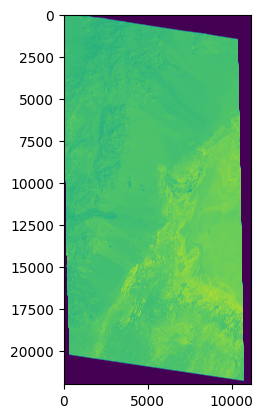

In [21]:
fig, ax = plt.subplots()
ax.imshow(imageToaBaseline[7, :, :])

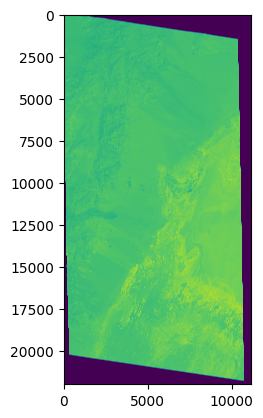

In [22]:
fig, ax = plt.subplots()
ax.imshow(imageToaEvhr[7, :, :])

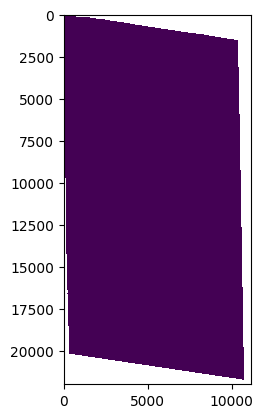

In [23]:
fig, ax = plt.subplots()
ax.imshow(imageToaDiff[7, :, :])


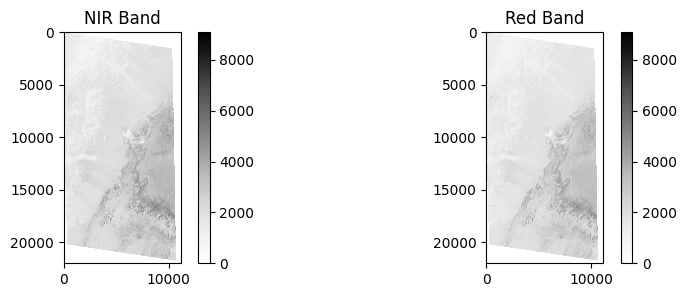

In [24]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,3)) # 2 axes on a 1x2 grid
# note that we could also use indexing for our axes:
# fig, ax = plt.subplots(1, 2)
# ax1 = ax[0]
image = imageToaEvhr
# find max reflectance to put them on the same colorbar scale
max_ref = np.amax([np.amax(image[3:,:]), np.amax(image[2:,:])])

# nir in first subplot
nir = ax1.imshow(image[3, :, :], cmap=plt.cm.Greys)
ax1.set_title("NIR Band")
nir.set_clim(vmin=0, vmax=max_ref)

fig.colorbar(nir, ax=ax1)

# Now red band in the second subplot
red = ax2.imshow(image[2, :, :], cmap=plt.cm.Greys)
ax2.set_title("Red Band")
red.set_clim(vmin=0, vmax=max_ref)
fig.colorbar(red, ax=ax2)



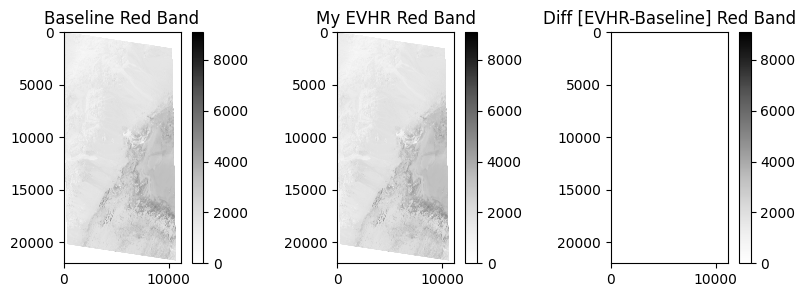

In [30]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(10,3)) # 2 axes on a 1x2 grid
# note that we could also use indexing for our axes:
# fig, ax = plt.subplots(1, 2)
# ax1 = ax[0]
image = imageToaEvhr
# find max reflectance to put them on the same colorbar scale
max_ref = np.amax([np.amax(image[3:,:]), np.amax(image[2:,:])])

# baseline red in first subplot
redBaseline = ax1.imshow(imageToaBaseline[2, :, :], cmap=plt.cm.Greys)
ax1.set_title("Baseline Red Band")
redBaseline.set_clim(vmin=0, vmax=max_ref)

fig.colorbar(redBaseline, ax=ax1)

# Now my red band in the second subplot
redEvhr = ax2.imshow(imageToaEvhr[2, :, :], cmap=plt.cm.Greys)
ax2.set_title("My EVHR Red Band")
redEvhr.set_clim(vmin=0, vmax=max_ref)
fig.colorbar(redEvhr, ax=ax2)

# Now diff between the two bands
diff = ax3.imshow(imageToaDiff[2, :, :], cmap=plt.cm.Greys)
ax3.set_title("Diff [EVHR-Baseline] Red Band")
diff.set_clim(vmin=0, vmax=max_ref)
fig.colorbar(diff, ax=ax3)
